In [1]:
using Pkg
Pkg.activate("/home/gridsan/aligho/Github_Projects/JJDFTX.jl/")
ENV["JULIA_REVISE_POLL"]="1";
using Revise

In [2]:
using PyPlot, PyCall, Peaks, Statistics, JJDFTX;

Your version of python is not linked to helper_scripts.py
Your version of python is not linked to the Atomic Simulation Environment


In [4]:
dir = "/home/gridsan/aligho/Github_Projects/JJDFTX.jl/src/read_prepared_data/../../data/Silver/"

"/home/gridsan/aligho/Github_Projects/JJDFTX.jl/src/read_prepared_data/../../data/Silver/"

In [5]:
Hwannier, cell_map = hwannier("wannier"), np.loadtxt("wannier.map.txt");
force_matrix, cellph_map = phonon_force_matrix("totalE");
Pwannier = pwannier("wannier");
Heph, celleph_map = hephwannier("wannier"), np.loadtxt("wannier.mapeph.txt");
lattice_vectors = loadlattice("wannier.out");

In [6]:
subsampling = returnfermikpoint(Hwannier, cell_map, 13, Val(3), num_blocks=10, mesh=10, histogram_width=1)

(Real[0.30289030669003103 0.4251992509984026 … 0.04526986239564734 0.3070772569873834; 0.3092730541514941 0.5296715775507499 … 0.7965667301380073 0.8878487776918578; 0.8544639848595579 0.35215523114588065 … 0.5653813208100877 0.3537090069045221], 0.127)

In [36]:
#Calculating the density of states at the fermi surface
JJDFTX.dosatmu(Hwannier, cell_map, 13, Val(3), mesh=10, histogram_width=1, num_blocks=50)

0.12810000000000002

In [38]:
# Calculating the decay time through Shankar's method
tau =  τ(Hwannier, cell_map, Pwannier, force_matrix, cellph_map,
    Heph, celleph_map, collect(0.01:0.01:1), 13, Val(:histogram), Val(3); histogram_width=1, supplysampling=subsampling, num_blocks=50, supplydos=0.128,  mesh=10, fracroom=1)

DOS at Fermi Energy is: 0.128
Sampling from 1270kpoints
Block: 1
Block: 2
Block: 3
Block: 4
Block: 5
Block: 6
Block: 7
Block: 8
Block: 9
Block: 10
Block: 11
Block: 12
Block: 13
Block: 14
Block: 15
Block: 16
Block: 17
Block: 18
Block: 19
Block: 20
Block: 21
Block: 22
Block: 23
Block: 24
Block: 25
Block: 26
Block: 27
Block: 28
Block: 29
Block: 30
Block: 31
Block: 32
Block: 33
Block: 34
Block: 35
Block: 36
Block: 37
Block: 38
Block: 39
Block: 40
Block: 41
Block: 42
Block: 43
Block: 44
Block: 45
Block: 46
Block: 47
Block: 48
Block: 49
Block: 50


100-element Vector{Float64}:
 32.181418968765826
 32.15810784540759
 32.12087193294995
 32.071896040216515
 32.013819705465224
 31.94943439241339
 31.881415867361618
 31.812127371710535
 31.743505925622237
 31.677024801213307
 31.613713859446577
 31.554216059807114
 31.498860690391872
  ⋮
 30.765357456386635
 30.763903898874023
 30.76248242053055
 30.76109197099374
 30.7597315452618
 30.75840018127115
 30.757096957627493
 30.7558209914792
 30.75457143652291
 30.753347481131673
 30.752148346596773
 30.750973285475705

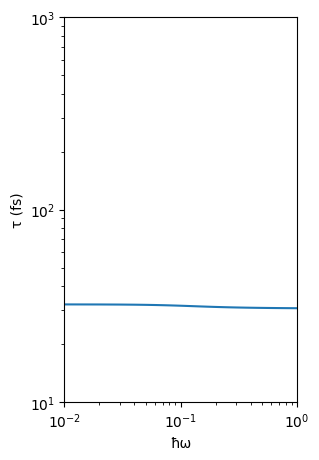

PyObject Text(24.000000000000007, 0.5, 'τ (fs)')

In [51]:
figure(figsize=(3, 5))
loglog(collect(0.01:0.01:1), tau)
ylim(10, 1000)
xlim(0.01, 1)
xlabel("ħω")
ylabel("τ (fs)")

In [26]:
tau_allen =  JJDFTX.τ_allen(Hwannier, cell_map, Pwannier, force_matrix, cellph_map,
    Heph, celleph_map, collect(0.01:0.01:1), 13, Val(3); 
mesh=2, supplydos=0.129, num_blocks=1000, fracroom=1, histogram_width=1)

DOS at Fermi Energy is: 0.129
Block: 1
Block: 2
Block: 3
Block: 4
Block: 5
Block: 6
Block: 7
Block: 8
Block: 9
Block: 10
Block: 11
Block: 12
Block: 13
Block: 14
Block: 15
Block: 16
Block: 17
Block: 18
Block: 19
Block: 20
Block: 21
Block: 22
Block: 23
Block: 24
Block: 25
Block: 26
Block: 27
Block: 28
Block: 29
Block: 30
Block: 31
Block: 32
Block: 33
Block: 34
Block: 35
Block: 36
Block: 37
Block: 38
Block: 39
Block: 40
Block: 41
Block: 42
Block: 43
Block: 44
Block: 45
Block: 46
Block: 47
Block: 48
Block: 49
Block: 50
Block: 51
Block: 52
Block: 53
Block: 54
Block: 55
Block: 56
Block: 57
Block: 58
Block: 59
Block: 60
Block: 61
Block: 62
Block: 63
Block: 64
Block: 65
Block: 66
Block: 67
Block: 68
Block: 69
Block: 70
Block: 71
Block: 72
Block: 73
Block: 74
Block: 75
Block: 76
Block: 77
Block: 78
Block: 79
Block: 80
Block: 81
Block: 82
Block: 83
Block: 84
Block: 85
Block: 86
Block: 87
Block: 88
Block: 89
Block: 90
Block: 91
Block: 92
Block: 93
Block: 94
Block: 95
Block: 96
Block: 97
Block: 98

Block: 753
Block: 754
Block: 755
Block: 756
Block: 757
Block: 758
Block: 759
Block: 760
Block: 761
Block: 762
Block: 763
Block: 764
Block: 765
Block: 766
Block: 767
Block: 768
Block: 769
Block: 770
Block: 771
Block: 772
Block: 773
Block: 774
Block: 775
Block: 776
Block: 777
Block: 778
Block: 779
Block: 780
Block: 781
Block: 782
Block: 783
Block: 784
Block: 785
Block: 786
Block: 787
Block: 788
Block: 789
Block: 790
Block: 791
Block: 792
Block: 793
Block: 794
Block: 795
Block: 796
Block: 797
Block: 798
Block: 799
Block: 800
Block: 801
Block: 802
Block: 803
Block: 804
Block: 805
Block: 806
Block: 807
Block: 808
Block: 809
Block: 810
Block: 811
Block: 812
Block: 813
Block: 814
Block: 815
Block: 816
Block: 817
Block: 818
Block: 819
Block: 820
Block: 821
Block: 822
Block: 823
Block: 824
Block: 825
Block: 826
Block: 827
Block: 828
Block: 829
Block: 830
Block: 831
Block: 832
Block: 833
Block: 834
Block: 835
Block: 836
Block: 837
Block: 838
Block: 839
Block: 840
Block: 841
Block: 842
Block: 843

100-element Vector{Float64}:
 866.715279901921
  46.7067695637177
  39.02657960444289
  36.20390576192881
  31.08838187197499
  30.306441844037582
  29.9418605990963
  30.078522821845983
  29.765111368907615
  29.03061181679781
  29.686183068182274
  29.05599622639496
  29.29224136884523
   ⋮
  29.85244527009273
  30.014482609328827
  30.238514889421364
  30.211926146289738
  30.344279325802358
  30.335957180050755
  30.36749320797822
  30.42754863850788
  30.55135875296379
  30.616232987090697
  30.705090187689862
  30.70195586205209

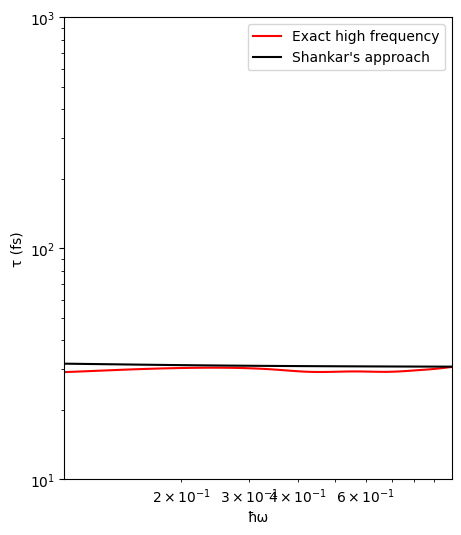

PyObject Text(24.000000000000007, 0.5, 'τ (fs)')

In [55]:
# comparison of exact high frequency result with Shankar's approach
figure(figsize=(5, 6))
loglog(collect(0.01:0.01:1)[10:end], smooth(tau_allen[10:end], win_len=30), color="red", label="Exact high frequency")
loglog(collect(0.01:0.01:1)[10:end], tau[10:end], color="black", label="Shankar's approach")
legend()
xlim(0.1, 1)
ylim(10, 1000)
gca().set_xticks([])
xlabel("ħω")
ylabel("τ (fs)")

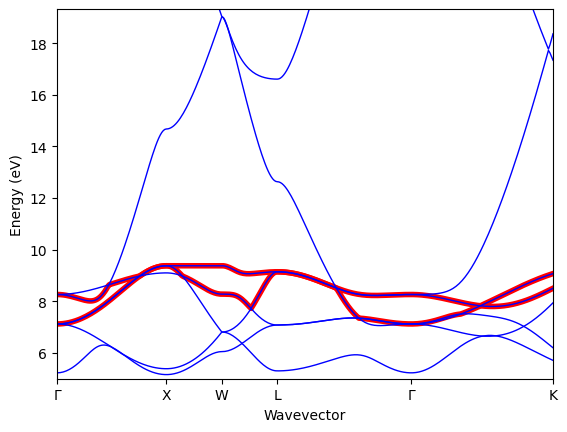

(5.0, 19.320093999999997)

In [13]:
# Plot of the wannierization scheme
plot_bands(Hwannier, cell_map, color="red", linewidth=4, whichbands=[4, 5])
plot_bands("totalE.bands.eigenvals", spin=1, color="blue", linewidth=1)
label_plots()
ylim(5, 0.71/eV)

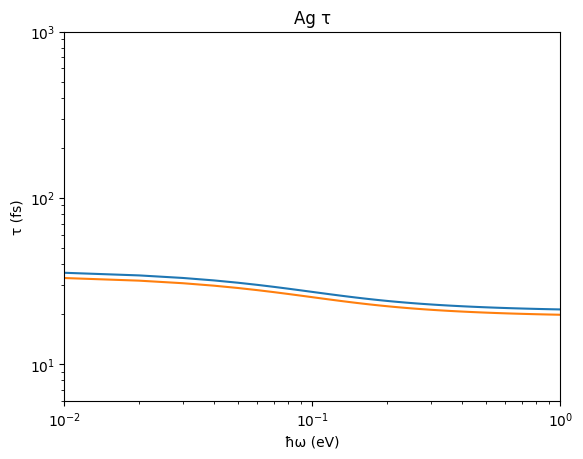

PyObject Text(24.000000000000007, 0.5, 'τ (fs)')

In [9]:
loglog(collect(0.01:0.01:1), tau)
loglog(collect(0.01:0.01:1), np.loadtxt("Ag_3D_tau.txt"))
ylim(6, 1000)
xlim(0.01, 1)
title("Ag τ")
xlabel("ħω (eV)")
ylabel("τ (fs)")

In [87]:
drude_conductivity(lattice_vectors, Hwannier, cell_map, Pwannier, 13, Val(3), mesh=6, num_blocks=1000, histogram_width=1, degeneracy=2)

here
Block: 1
Block: 2
Block: 3
Block: 4
Block: 5
Block: 6
Block: 7
Block: 8
Block: 9
Block: 10
Block: 11
Block: 12
Block: 13
Block: 14
Block: 15
Block: 16
Block: 17
Block: 18
Block: 19
Block: 20
Block: 21
Block: 22
Block: 23
Block: 24
Block: 25
Block: 26
Block: 27
Block: 28
Block: 29
Block: 30
Block: 31
Block: 32
Block: 33
Block: 34
Block: 35
Block: 36
Block: 37
Block: 38
Block: 39
Block: 40
Block: 41
Block: 42
Block: 43
Block: 44
Block: 45
Block: 46
Block: 47
Block: 48
Block: 49
Block: 50
Block: 51
Block: 52
Block: 53
Block: 54
Block: 55
Block: 56
Block: 57
Block: 58
Block: 59
Block: 60
Block: 61
Block: 62
Block: 63
Block: 64
Block: 65
Block: 66
Block: 67
Block: 68
Block: 69
Block: 70
Block: 71
Block: 72
Block: 73
Block: 74
Block: 75
Block: 76
Block: 77
Block: 78
Block: 79
Block: 80
Block: 81
Block: 82
Block: 83
Block: 84
Block: 85
Block: 86
Block: 87
Block: 88
Block: 89
Block: 90
Block: 91
Block: 92
Block: 93
Block: 94
Block: 95
Block: 96
Block: 97
Block: 98
Block: 99
Block: 100
Blo

Block: 756
Block: 757
Block: 758
Block: 759
Block: 760
Block: 761
Block: 762
Block: 763
Block: 764
Block: 765
Block: 766
Block: 767
Block: 768
Block: 769
Block: 770
Block: 771
Block: 772
Block: 773
Block: 774
Block: 775
Block: 776
Block: 777
Block: 778
Block: 779
Block: 780
Block: 781
Block: 782
Block: 783
Block: 784
Block: 785
Block: 786
Block: 787
Block: 788
Block: 789
Block: 790
Block: 791
Block: 792
Block: 793
Block: 794
Block: 795
Block: 796
Block: 797
Block: 798
Block: 799
Block: 800
Block: 801
Block: 802
Block: 803
Block: 804
Block: 805
Block: 806
Block: 807
Block: 808
Block: 809
Block: 810
Block: 811
Block: 812
Block: 813
Block: 814
Block: 815
Block: 816
Block: 817
Block: 818
Block: 819
Block: 820
Block: 821
Block: 822
Block: 823
Block: 824
Block: 825
Block: 826
Block: 827
Block: 828
Block: 829
Block: 830
Block: 831
Block: 832
Block: 833
Block: 834
Block: 835
Block: 836
Block: 837
Block: 838
Block: 839
Block: 840
Block: 841
Block: 842
Block: 843
Block: 844
Block: 845
Block: 846

3×3 Matrix{Float64}:
 1.94345      0.00330916   0.0124504
 0.00330916   1.9378      -0.00712037
 0.0124504   -0.00712037   1.94799

In [115]:
c = interbandsigma(lattice_vectors, Hwannier, cell_map, Pwannier, 13, Val(3), mesh=5, num_blocks=10)

Block: 1
Block: 2
Block: 3
Block: 4
Block: 5
Block: 6
Block: 7
Block: 8
Block: 9
Block: 10


3×3×200 Array{ComplexF64, 3}:
[:, :, 1] =
 NaN+NaN*im  NaN+NaN*im  NaN+NaN*im
 NaN+NaN*im  NaN+NaN*im  NaN+NaN*im
 NaN+NaN*im  NaN+NaN*im  NaN+NaN*im

[:, :, 2] =
 0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im

[:, :, 3] =
 0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im

...

[:, :, 198] =
  -0.0365984+0.0im         -0.00385111+8.79348e-7im  -0.00127156+6.38429e-8im
 -0.00385111-8.79348e-7im   -0.0351279+0.0im           0.0071184-5.64845e-7im
 -0.00127156-6.38429e-8im    0.0071184+5.64845e-7im   -0.0341789+0.0im

[:, :, 199] =
  -0.0425628+0.0im         0.000710009+5.13502e-7im   -0.0126695+5.21014e-7im
 0.000710009-5.13502e-7im   -0.0663587+0.0im         -0.00644494-5.67325e-7im
  -0.0126695-5.21014e-7im  -0.00644494+5.67325e-7im    -0.048353+0.0im

[:, :, 200] =
  -0.0408227+0.0im          0.00961401-5.55272e-8im  -0.00377132-3.74769e-7im
  0.00961401+5.55272e-8im   -0.0482786+0.0im

In [56]:
Es, Ds = density_of_states(Hwannier, cell_map, Val(3), mesh=10, num_blocks=20, histogram_width=10, monte_carlo=true)

([4.162161332419592, 4.2620222309962355, 4.36188312957288, 4.461744028149524, 4.561604926726168, 4.661465825302812, 4.761326723879456, 4.8611876224561, 4.961048521032744, 5.060909419609388  …  30.9248821509602, 31.024743049536845, 31.12460394811349, 31.224464846690132, 31.324325745266776, 31.42418664384342, 31.524047542420064, 31.623908440996708, 31.72376933957335, 31.823630238149995], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])

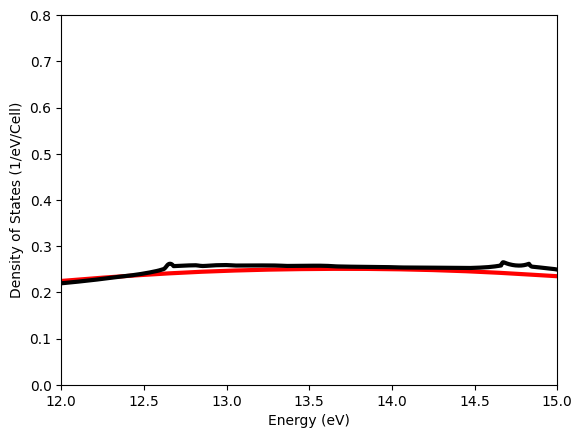

(12.0, 15.0)

In [62]:
plot(Es, smooth(Ds*2), linewidth=3, color="red")
density_of_states("totalE.dos", linewidth=3, color="black")
ylim(0, 0.8)
xlim(12, 15)